# 04 — Результаты (Стадия 3)

Ноутбук **тонкий** (§7): вся логика построения графиков — в `src/viz/results.py`, здесь только вызовы и сохранение. Числа не пересчитываются: EER, доверительные интервалы, матрицы ошибок и разбивка по атакам читаются из `eval_metrics.json`, кривые DET/ROC рисуются из `scores.parquet` (§6).

**Предусловие:** прогнана Стадия 3 —
```bash
python -m src.evaluate --config experiments/<exp>.yaml
```

Ноутбук обязан проходить **Restart & Run All** сверху вниз без ошибок (§7).

In [1]:
import sys
from pathlib import Path

# Корень проекта в sys.path — ноутбук лежит на уровень глубже.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.config import Paths
from src.viz import results as R
from src.viz.style import apply_style, save_figure

apply_style()
PATHS = Paths(root=ROOT)

#: Имя эксперимента = поле `name` из experiments/<exp>.yaml.
EXP = "smoke_lfcc_statpool"

In [2]:
scores = R.load_scores(EXP, PATHS)
metrics = R.load_metrics(EXP, PATHS)

ckpt = metrics["checkpoint"]
cov = metrics["coverage"]
print(f"эксперимент : {metrics['experiment']}  (веса {metrics['weights']}, эпоха {ckpt['epoch']})")
print(f"модель      : {ckpt['model_name']} {ckpt['model_params']}")
print(f"признак     : {ckpt['feature']} C={ckpt['in_channels']} t_fixed={ckpt['t_fixed']} окно={metrics['window']}")
print(f"покрытие    : {cov['n_scored']}/{cov['n_requested']} ({cov['ratio']:.4f})")
print(f"скор        : {metrics['score_convention']}")
if metrics.get("subset"):
    print(f"ВНИМАНИЕ: оценка на подвыборке {metrics['subset']} — не итоговые числа (§6.4)")

эксперимент : smoke_lfcc_statpool  (веса best.pt, эпоха 5)
модель      : statpool_mlp {'hidden': 128, 'dropout': 0.3}
признак     : lfcc C=60 t_fixed=400 окно=fixed
покрытие    : 2000/2000 (1.0000)
скор        : сырой логит модели; больше ⇒ спуф (label=1, §6.1)
ВНИМАНИЕ: оценка на подвыборке {'n_test': 2000, 'seed': 1337} — не итоговые числа (§6.4)


## Сводная таблица

Одна строка на датасет. Общего EER по смеси датасетов нет намеренно: он смешал бы разные домены и разные классовые пропорции в одно неинтерпретируемое число. Кросс-датасетный вывод (§8) читается сравнением строк.

Интервал — перцентильный бутстрэп, стратифицированный по классу (§6.4). Он покрывает разброс из-за конечности **теста**, но не разброс из-за случайности обучения.

In [3]:
table = R.eer_table(metrics)
table

,dataset_id,N,bonafide,spoof,"EER, %","CI нижн., %","CI верхн., %"
0,asvspoof2019_la,1970,203,1767,13.41,10.47,15.76
1,for-2seconds,30,15,15,86.67,73.33,100.00


## DET-кривая

Основной график результатов в анти-спуфинге (§8). Оси в нормальных отклонениях, точка на диагонали `FPR = FNR` — это EER.

[PosixPath('/home/vano/Programming/Study/Python/ITMO-NIR-MAG/reports/figures/smoke_lfcc_statpool_det.pdf')]

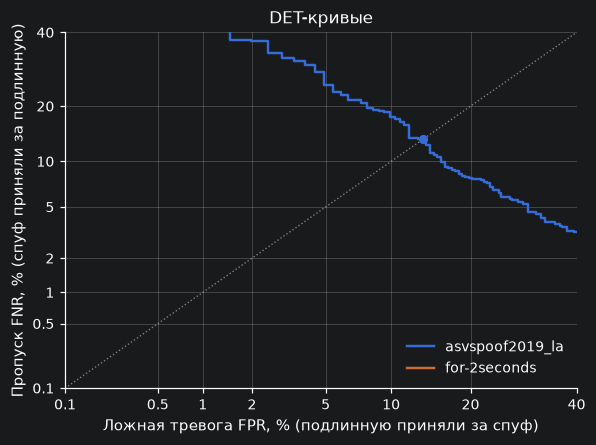

In [4]:
fig = R.plot_det(scores, metrics)
save_figure(fig, f"{EXP}_det", paths=PATHS)  # вектор (§7)

[PosixPath('/home/vano/Programming/Study/Python/ITMO-NIR-MAG/reports/figures/smoke_lfcc_statpool_roc.pdf')]

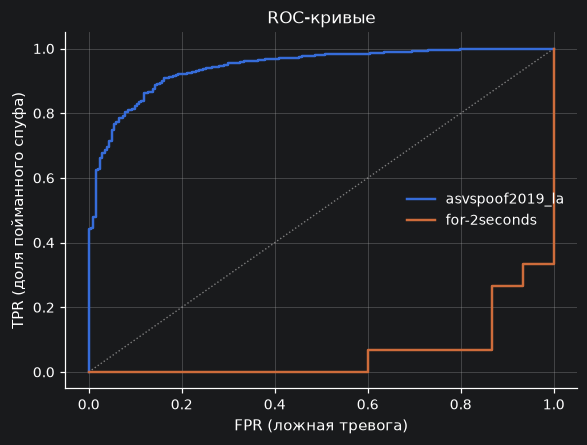

In [5]:
fig = R.plot_roc(scores)
save_figure(fig, f"{EXP}_roc", paths=PATHS)

## Матрицы ошибок

Две рабочие точки на каждый датасет:

* **порог с валидации** — честная точка: порог выбран до теста;
* **порог EER** — подобран на самом тесте, поэтому это иллюстрация распределения ошибок, а не оценка обобщения (§6.5).

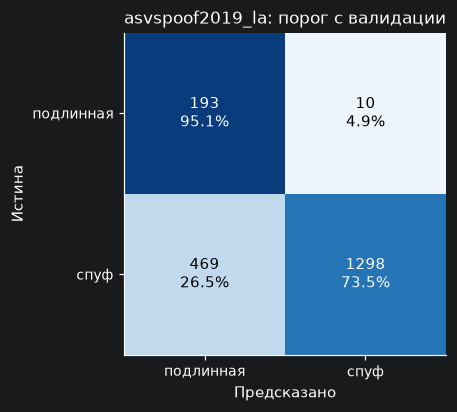

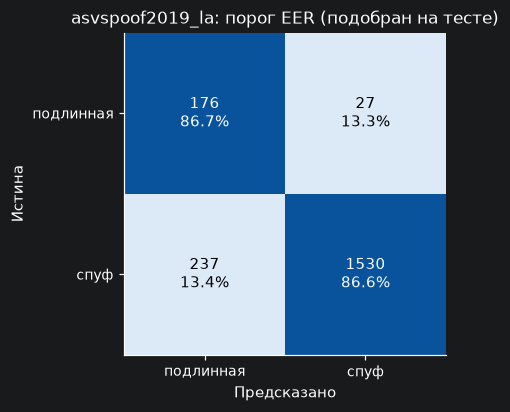

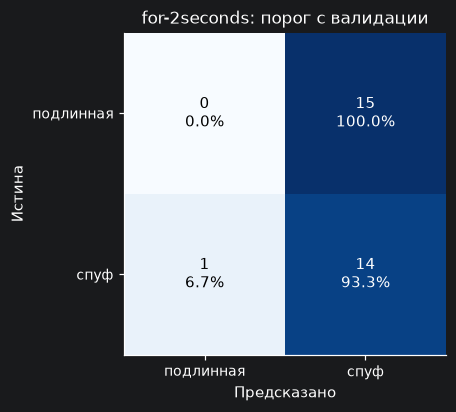

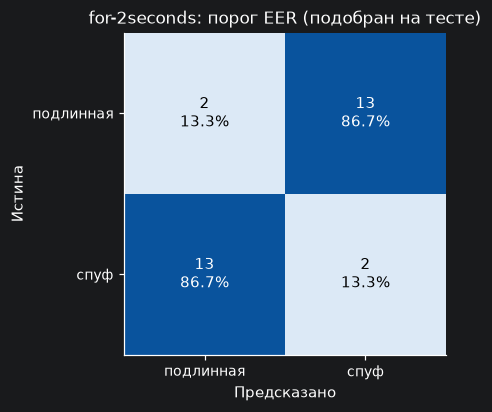

In [6]:
for ds in metrics["per_dataset"]:
    for at in ("val", "eer"):
        try:
            fig = R.plot_confusion(metrics, ds, at=at)
        except KeyError:
            continue  # порога валидации может не быть (напр. val-EER был NaN)
        save_figure(fig, f"{EXP}_{ds}_cm_{at}", paths=PATHS, formats=("png",))

## EER по атакам

Агрегированная метрика скрывает, на каких атаках метод проседает; в обзоре это отмечено как слабость ряда работ, поэтому разбивка — лёгкий измеримый вклад (§8). Строится только для датасетов с размеченным `attack_type`.

for-2seconds: у for-2seconds нет разбивки по атакам (attack_type не размечен, §6.1)


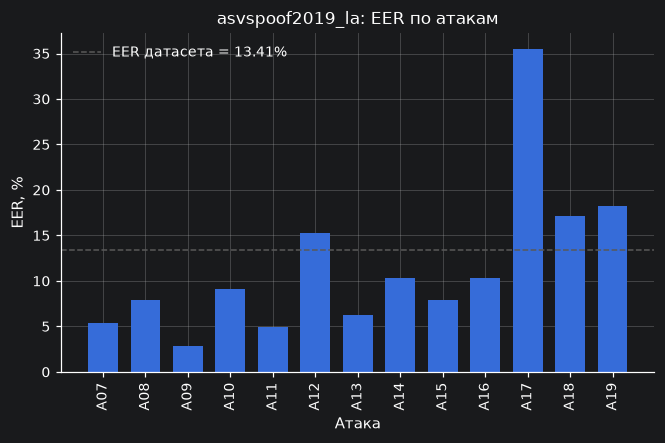

In [7]:
for ds in metrics["per_dataset"]:
    try:
        fig = R.plot_eer_by_attack(metrics, ds)
    except ValueError as e:
        print(f"{ds}: {e}")
        continue
    save_figure(fig, f"{EXP}_{ds}_eer_by_attack", paths=PATHS)